# Cross-model comparison and analysis

This notebook is the main analysis for the report. It loads predictions from all four models and produces:

1. **Master comparison table** — accuracy + macro-F1 for each model, overall and by agreement tier.
2. **Confusion matrices** for each model.
3. **Agreement-tier breakdown** chart that answers RQ2.
4. **Error analysis** — example misclassifications by the best model.

Prerequisites: every teammate has committed their `*_predictions.csv` to `predictions/`. Expected files:
- `predictions/tfidf_logreg_predictions.csv`     (Gavin)
- `predictions/tfidf_logreg_lm_predictions.csv`  (Noah)
- `predictions/bert_finetuned_predictions.csv`   (Avi)
- `predictions/finbert_finetuned_predictions.csv` (Max)

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.exists('financial-sentiment-comparison'):
        !git clone https://github.com/maximusrome/financial-sentiment-comparison.git
    %cd financial-sentiment-comparison
    !pip install -q pandas scikit-learn pyarrow matplotlib seaborn

from pathlib import Path
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

Cloning into 'financial-sentiment-comparison'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 107 (delta 52), reused 60 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 3.50 MiB | 4.90 MiB/s, done.
Resolving deltas: 100% (52/52), done.
/content/financial-sentiment-comparison


## Load all predictions

In [2]:
from evaluation import (
    load_all_predictions, build_comparison_table, pretty_comparison_table,
    evaluate_predictions, plot_confusion_matrix,
    plot_agreement_tier_comparison, find_misclassifications, TIER_ORDER,
)

preds = load_all_predictions('predictions')
print(f'Found predictions for {len(preds)} models:')
for name, df in preds.items():
    print(f'  {name:25s}  n={len(df)}')

Found predictions for 4 models:
  bert_finetuned             n=484
  finbert_finetuned          n=484
  tfidf_logreg_lm            n=484
  tfidf_logreg               n=484


## Master comparison table

This is the main results table for the report.

In [3]:
table = build_comparison_table(preds)
table.to_csv('results/tables/comparison_table.csv', index=False)
table.round(4)

,model,tier,accuracy,macro_f1,n
0,tfidf_logreg,overall,0.7727,0.7211,484
1,tfidf_logreg,100,0.9071,0.8843,226
2,tfidf_logreg,75-99,0.7583,0.6395,120
3,tfidf_logreg,66-74,0.5526,0.3671,76
4,tfidf_logreg,50-65,0.5806,0.5475,62
5,tfidf_logreg_lm,overall,0.7521,0.6775,484
6,tfidf_logreg_lm,100,0.8717,0.8148,226
7,tfidf_logreg_lm,75-99,0.7500,0.6321,120
8,tfidf_logreg_lm,66-74,0.5526,0.4051,76
9,tfidf_logreg_lm,50-65,0.5645,0.5159,62


In [4]:
# Pivoted 'pretty' view for easy reading
wide = pretty_comparison_table(table)
wide

accuracy                                 macro_f1          \
tier               overall     100   75-99   66-74   50-65  overall     100   
model                                                                         
tfidf_logreg        0.7727  0.9071  0.7583  0.5526  0.5806   0.7211  0.8843   
tfidf_logreg_lm     0.7521  0.8717  0.7500  0.5526  0.5645   0.6775  0.8148   
bert_finetuned      0.8347  0.9602  0.8667  0.5658  0.6452   0.8093  0.9385   
finbert_finetuned   0.8719  0.9735  0.9000  0.7237  0.6290   0.8599  0.9574   

                                           
tier                75-99   66-74   50-65  
model                                      
tfidf_logreg       0.6395  0.3671  0.5475  
tfidf_logreg_lm    0.6321  0.4051  0.5159  
bert_finetuned     0.8167  0.5331  0.6652  
finbert_finetuned  0.8677  0.7364  0.6645

## Confusion matrices (one per model, overall)

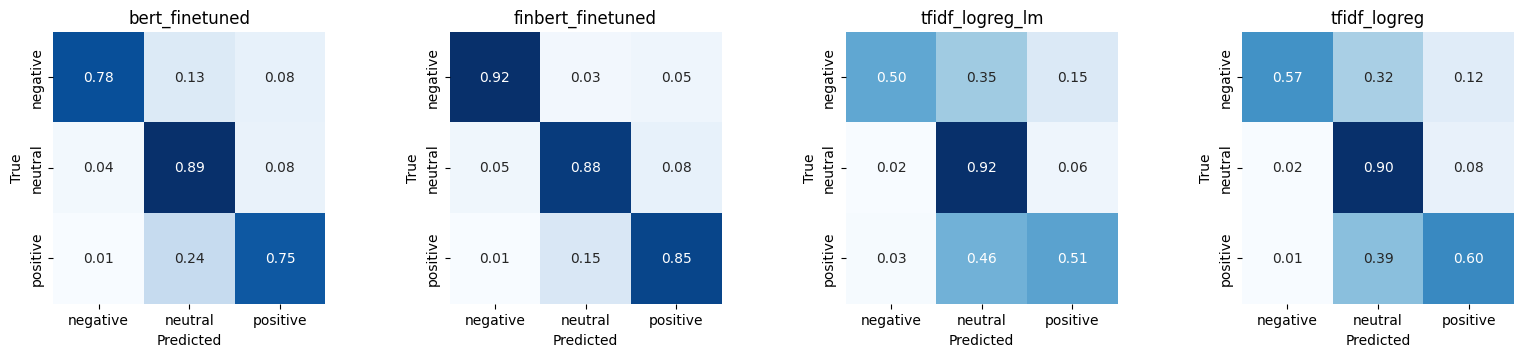

In [5]:
import matplotlib.pyplot as plt

n_models = len(preds)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 3.6))
if n_models == 1:
    axes = [axes]

for ax, (name, _) in zip(axes, preds.items()):
    res = evaluate_predictions(f'predictions/{name}_predictions.csv')
    plot_confusion_matrix(res['overall']['confusion_matrix'],
                          title=name, ax=ax)

plt.tight_layout()
plt.savefig('results/figures/all_confusion_matrices.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Agreement-tier breakdown (RQ2)

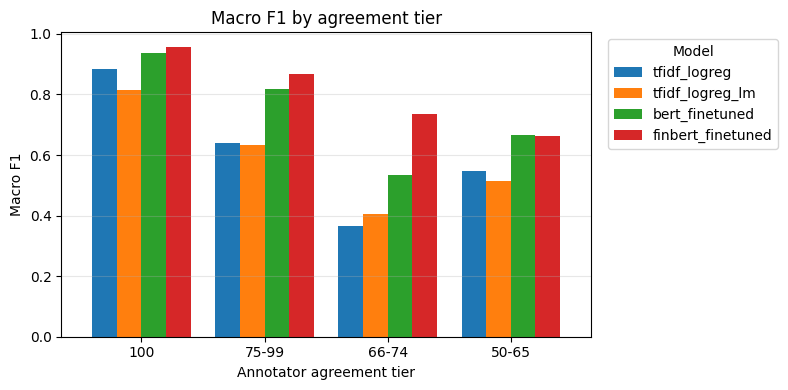

In [6]:
ax = plot_agreement_tier_comparison(table, metric='macro_f1')
plt.tight_layout()
plt.savefig('results/figures/agreement_tier_f1.png', dpi=150,
            bbox_inches='tight')
plt.show()

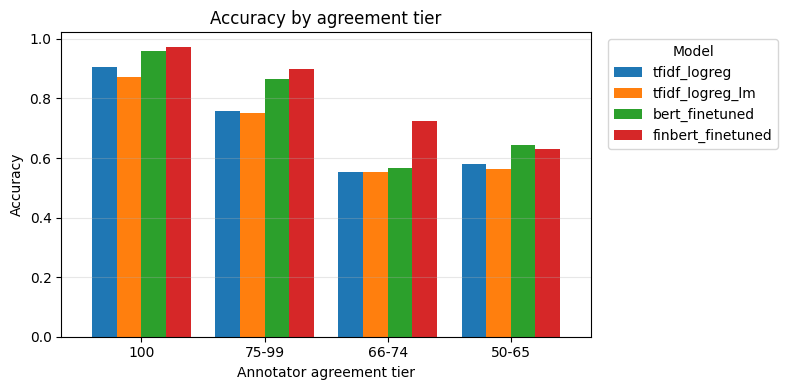

In [7]:
ax = plot_agreement_tier_comparison(table, metric='accuracy')
plt.tight_layout()
plt.savefig('results/figures/agreement_tier_accuracy.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Model-vs-model agreement

Useful sanity check: if BERT and FinBERT agree on 95% of predictions, the "domain-specific pretraining" story is weaker.

In [8]:
import pandas as pd
import numpy as np

# Build a matrix of predictions
merged = None
for name, df in preds.items():
    d = df[['sentence_id', 'predicted_label']].rename(
        columns={'predicted_label': name})
    merged = d if merged is None else merged.merge(d, on='sentence_id')

names = list(preds.keys())
n = len(names)
mat = np.zeros((n, n))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        mat[i, j] = (merged[a] == merged[b]).mean()

agreement_df = pd.DataFrame(mat, index=names, columns=names).round(3)
agreement_df

,bert_finetuned,finbert_finetuned,tfidf_logreg_lm,tfidf_logreg
bert_finetuned,1.000,0.932,0.785,0.833
finbert_finetuned,0.932,1.000,0.750,0.787
tfidf_logreg_lm,0.785,0.750,1.000,0.845
tfidf_logreg,0.833,0.787,0.845,1.000


## Qualitative error analysis — FinBERT

In [9]:
errors = find_misclassifications(
    'predictions/finbert_finetuned_predictions.csv', n_examples=8)
cols = ['sentence_id', 'agreement_tier', 'label_name', 'predicted_label', 'text']
errors[cols]

,sentence_id,agreement_tier,label_name,predicted_label,text
0,s00697,100,negative,positive,"ADP News - Apr 22 , 2009 - Finnish business in..."
1,s04179,50-65,negative,neutral,EB announced in its stock exchange release on ...
2,s00733,75-99,negative,positive,Operating loss increased to EUR 17mn from a lo...
3,s04097,100,neutral,negative,"The company reported a profit of 800,000 euro ..."
4,s01272,50-65,neutral,positive,"KONE , headquartered in Espoo , Finland , is o..."
5,s02566,66-74,neutral,positive,"Stora Enso , a global paper , packaging and wo..."
6,s04569,75-99,neutral,negative,"In Asia earlier , Japan 's Nikkei index fell 0..."
7,s02292,100,positive,negative,Profit for the period was EUR 15.6 mn compared...


## Key numbers for the report

Run this cell last to produce a cleanly formatted summary you can paste into the report or slides.

In [10]:
print('=== Summary for report ===\n')
overall = table[table['tier'] == 'overall'].set_index('model')
for model, row in overall.iterrows():
    print(f'{model:25s}  acc={row["accuracy"]:.4f}  '
          f'macro_f1={row["macro_f1"]:.4f}')

print('\n=== By agreement tier (macro-F1) ===\n')
pivot = table.pivot(index='model', columns='tier', values='macro_f1').round(4)
print(pivot.to_string())

=== Summary for report ===

tfidf_logreg               acc=0.7727  macro_f1=0.7211
tfidf_logreg_lm            acc=0.7521  macro_f1=0.6775
bert_finetuned             acc=0.8347  macro_f1=0.8093
finbert_finetuned          acc=0.8719  macro_f1=0.8599

=== By agreement tier (macro-F1) ===

tier               overall     100   75-99   66-74   50-65
model                                                     
tfidf_logreg        0.7211  0.8843  0.6395  0.3671  0.5475
tfidf_logreg_lm     0.6775  0.8148  0.6321  0.4051  0.5159
bert_finetuned      0.8093  0.9385  0.8167  0.5331  0.6652
finbert_finetuned   0.8599  0.9574  0.8677  0.7364  0.6645
